<h1 style="background: linear-gradient(180deg, #4a1486, #6a51a3); color: white; font-family: 'Raleway', sans-serif; padding: 10px 20px; border-radius: 10px; text-align: center; font-weight:500;">
<i><b>Spoiler Alert.</b> Así te va a ir en la escuela</i>
</h1>
<br>

 * Daniela Flores Quiroz
 * José Armando Ramírez Islas

---

## Importar bibliotecas

In [46]:
#BASICS
import pandas as pd
import numpy as np 

#VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

#PREPROCESSING
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA

#MODEL
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

#METRICS
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error, r2_score

#UTILS
import warnings

warnings.filterwarnings('ignore')

## ETL

### Extracción

In [47]:
raw =  pd.read_csv('./data/StudentPerformanceFactors.csv')

In [48]:
print(raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Podemos ver que tenemos datos nulos en algunas columnas

In [49]:
raw.isnull().sum() * 100 / raw.shape[0]

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [50]:
raw.sample(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
4586,26,62,Medium,Medium,No,6,59,Medium,Yes,1,Medium,Medium,Public,Neutral,3,No,High School,Moderate,Male,63
64,25,98,Low,High,Yes,8,56,Medium,No,0,Medium,High,Private,Neutral,3,No,Postgraduate,Near,Male,71
1644,14,86,Low,Low,Yes,6,77,Medium,Yes,3,High,Medium,Private,Neutral,3,No,High School,Far,Male,65
411,13,70,High,High,No,6,81,Medium,Yes,2,Medium,Low,Public,Positive,2,No,Postgraduate,Near,Male,66
5790,10,64,Medium,Low,No,9,76,Low,Yes,1,Low,Medium,Private,Positive,1,No,High School,Near,Female,58
5125,16,82,Medium,Medium,No,7,56,Low,Yes,0,High,High,Private,Negative,1,Yes,High School,Far,Female,79
944,31,75,Medium,Medium,No,7,90,Low,Yes,2,Medium,High,Public,Neutral,2,Yes,High School,Moderate,Male,68
3922,18,74,Medium,High,Yes,8,91,Medium,Yes,0,Medium,High,Private,Positive,2,No,High School,Near,Female,67
4667,30,61,Low,High,Yes,8,82,Low,Yes,2,Low,High,Public,Neutral,3,No,Postgraduate,Near,Female,68
6501,13,79,High,Medium,No,9,53,Medium,No,1,Medium,Medium,Private,Positive,2,No,College,Moderate,Male,63


In [51]:
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Transformación

#### Nulos

In [52]:
raw = raw.dropna()

#### Codificación Ordinaria _(Ordinal Encoding)_ 

In [53]:
#PARENTAL INVOLVEMENT
involvement = raw['Parental_Involvement'].unique().tolist()
encoder = OrdinalEncoder(categories=[involvement])
raw['Parental_Involvement'] = encoder.fit_transform(raw[['Parental_Involvement']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,0.0,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,1.0,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,1.0,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [54]:
#ACCESS TO RESORUCES
access = raw['Access_to_Resources'].unique().tolist()[::-1]
encoder = OrdinalEncoder(categories=[access])
raw['Access_to_Resources'] = encoder.fit_transform(raw[['Access_to_Resources']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [55]:
#MOTIVATION LEVEL
motivation = raw['Motivation_Level'].unique().tolist()
motivation
encoder = OrdinalEncoder(categories=[motivation])
raw['Motivation_Level'] = encoder.fit_transform(raw[['Motivation_Level']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [56]:
#FAMILY INCOME
income = raw['Family_Income'].unique().tolist()
income
encoder = OrdinalEncoder(categories=[income])
raw['Family_Income'] = encoder.fit_transform(raw[['Family_Income']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,High,Public,Neutral,4,No,College,Near,Female,70


In [57]:
#TEACHER QUALITY
teacher = ['Low', 'Medium', 'High']
teacher
encoder = OrdinalEncoder(categories=[teacher])
raw['Teacher_Quality'] = encoder.fit_transform(raw[['Teacher_Quality']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,Positive,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,Neutral,4,No,College,Near,Female,70


In [58]:
#PEER INFLUENCE
peer = ['Negative', 'Neutral', 'Positive']
encoder = OrdinalEncoder(categories=[peer])
raw['Peer_Influence'] = encoder.fit_transform(raw[['Peer_Influence']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,2.0,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,0.0,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,1.0,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,0.0,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,1.0,4,No,College,Near,Female,70


In [59]:
#PARENTAL EDUCATION LEVEL
edu_level = raw['Parental_Education_Level'].unique().tolist()
encoder = OrdinalEncoder(categories=[edu_level])
raw['Parental_Education_Level'] = encoder.fit_transform(raw[['Parental_Education_Level']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,2.0,3,No,0.0,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,0.0,4,No,1.0,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,1.0,4,No,2.0,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,0.0,4,No,0.0,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,1.0,4,No,1.0,Near,Female,70


In [60]:
#DISTANCE FROM HOME
distance = raw['Distance_from_Home'].unique().tolist()
encoder = OrdinalEncoder(categories=[distance])
raw['Distance_from_Home'] = encoder.fit_transform(raw[['Distance_from_Home']])
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,2.0,3,No,0.0,0.0,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,0.0,4,No,1.0,1.0,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,1.0,4,No,2.0,0.0,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,0.0,4,No,0.0,1.0,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,1.0,4,No,1.0,0.0,Female,70


In [61]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6378 non-null   int64  
 1   Attendance                  6378 non-null   int64  
 2   Parental_Involvement        6378 non-null   float64
 3   Access_to_Resources         6378 non-null   float64
 4   Extracurricular_Activities  6378 non-null   object 
 5   Sleep_Hours                 6378 non-null   int64  
 6   Previous_Scores             6378 non-null   int64  
 7   Motivation_Level            6378 non-null   float64
 8   Internet_Access             6378 non-null   object 
 9   Tutoring_Sessions           6378 non-null   int64  
 10  Family_Income               6378 non-null   float64
 11  Teacher_Quality             6378 non-null   float64
 12  School_Type                 6378 non-null   object 
 13  Peer_Influence              6378 non-n

#### Codificación con etiquetas _(Label Encoding)_

In [62]:
cat = raw.select_dtypes('object')
for col in cat.columns.values:
    le = LabelEncoder()
    raw[col] = le.fit_transform(raw[col])
raw

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,0,7,73,0.0,1,0,0.0,1.0,1,2.0,3,0,0.0,0.0,1,67
1,19,64,0.0,1.0,0,8,59,0.0,1,2,1.0,1.0,1,0.0,4,0,1.0,1.0,0,61
2,24,98,1.0,1.0,1,7,91,1.0,1,2,1.0,1.0,1,1.0,4,0,2.0,0.0,1,74
3,29,89,0.0,1.0,1,8,98,1.0,1,1,1.0,1.0,1,0.0,4,0,0.0,1.0,1,71
4,19,92,1.0,1.0,1,6,65,1.0,1,3,1.0,2.0,1,1.0,4,0,1.0,0.0,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2.0,1.0,0,7,76,1.0,1,1,2.0,1.0,1,2.0,2,0,0.0,0.0,0,68
6603,23,76,2.0,1.0,0,8,81,1.0,1,3,0.0,2.0,1,2.0,2,0,0.0,0.0,0,69
6604,20,90,1.0,0.0,1,6,65,0.0,1,3,0.0,1.0,1,0.0,2,0,2.0,0.0,0,68
6605,10,86,2.0,2.0,1,6,91,2.0,1,2,0.0,1.0,0,2.0,3,0,0.0,2.0,0,68


#### Valores atípicos

In [63]:
raw.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6378.000000,6378.000000,6378.00000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,1.08545,1.098150,0.596896,7.034964,75.066165,0.907965,0.923957,1.495296,0.788021,1.197241,0.695202,1.191753,2.972719,0.104735,0.705394,0.503763,0.578238,67.252117
std,5.985460,11.550723,0.69502,0.698635,0.490560,1.468033,14.400389,0.695758,0.265087,1.233984,0.743526,0.601064,0.460358,0.756394,1.028926,0.306236,0.780570,0.670442,0.493880,3.914217
min,1.000000,60.000000,0.00000,0.000000,0.000000,4.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,1.00000,1.000000,0.000000,6.000000,63.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,65.000000
50%,20.000000,80.000000,1.00000,1.000000,1.000000,7.000000,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,1.000000,67.000000
75%,24.000000,90.000000,2.00000,2.000000,1.000000,8.000000,88.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,4.000000,0.000000,1.000000,1.000000,1.000000,69.000000
max,44.000000,100.000000,2.00000,2.000000,1.000000,10.000000,100.000000,2.000000,1.000000,8.000000,2.000000,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,2.000000,1.000000,101.000000


In [64]:
# Calcular el rango intercuartílico (IQR)
Q1 = raw.quantile(0.25)
Q3 = raw.quantile(0.75)
IQR = Q3 - Q1

# Filtrar los outliers
raw = raw[~((raw < (Q1 - 1.5 * IQR)) | (raw > (Q3 + 1.5 * IQR))).any(axis=1)]
raw.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,4837.000000,4837.00000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.0,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.0,4837.000000,4837.000000,4837.000000,4837.000000
mean,20.034526,79.99173,1.089932,1.095307,0.598718,7.041141,75.077941,0.914823,1.0,1.285508,0.785611,1.199917,0.698160,1.191234,2.959066,0.0,0.707670,0.505685,0.583006,67.165392
std,5.783080,11.50344,0.690219,0.699324,0.490209,1.471877,14.386385,0.693660,0.0,0.973248,0.739229,0.601501,0.459104,0.755201,1.018836,0.0,0.782702,0.670650,0.493113,3.210743
min,4.000000,60.00000,0.000000,0.000000,0.000000,4.000000,50.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,59.000000
25%,16.000000,70.00000,1.000000,1.000000,0.000000,6.000000,63.000000,0.000000,1.0,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.000000,0.000000,65.000000
50%,20.000000,80.00000,1.000000,1.000000,1.000000,7.000000,75.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.0,1.000000,0.000000,1.000000,67.000000
75%,24.000000,90.00000,2.000000,2.000000,1.000000,8.000000,87.000000,1.000000,1.0,2.000000,1.000000,2.000000,1.000000,2.000000,4.000000,0.0,1.000000,1.000000,1.000000,69.000000
max,36.000000,100.00000,2.000000,2.000000,1.000000,10.000000,100.000000,2.000000,1.0,3.000000,2.000000,2.000000,1.000000,2.000000,6.000000,0.0,2.000000,2.000000,1.000000,75.000000


### Carga

In [65]:
df = raw.copy()

## EDA

In [ ]:
np.VisibleDeprecationWarning = Warning
report = sv.analyze(df)
report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


/usr/lib/python3.10/subprocess.py:1072: ResourceWarning: subprocess 10757 is still running
  _warn("subprocess %s is still running" % self.pid,


/snap/core20/current/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /home/armando/snap/code/common/.cache/gio-modules/libgiolibproxy.so


Abriendo en la sesión del explorador existente.


<Axes: title={'center': 'Matriz de correlación'}>

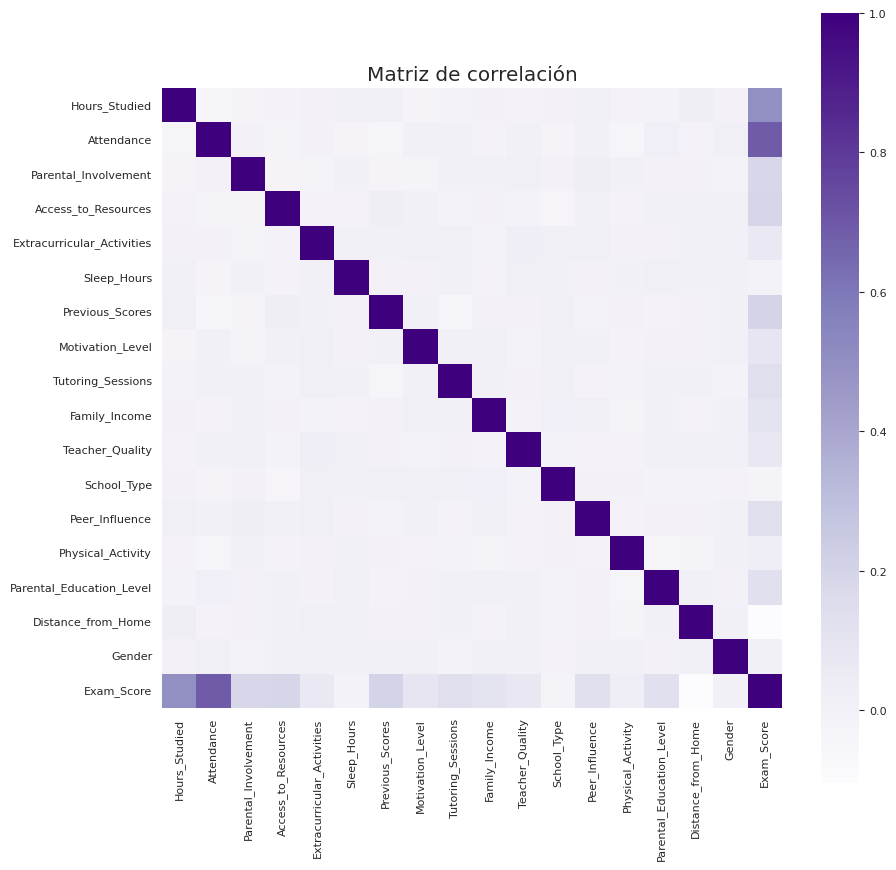

In [67]:
cm = df.drop(columns=['Internet_Access', 'Learning_Disabilities']).corr()

sns.set_style('white')
plt.figure(figsize=(10,10))
plt.title('Matriz de correlación')
sns.heatmap(cm, cmap='Purples', square=True)

## Modelado

In [68]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=19, shuffle=True)

In [70]:
modelos = [LinearRegression(),
          HuberRegressor(max_iter=1000), 
          RANSACRegressor(),
          XGBRegressor()]

In [91]:
def evaluar_modelos(modelos, X_train, y_train, X_test, y_test):
    metricas = {}
    
    for modelo in modelos:
        cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='r2')
        
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        metricas[modelo.__class__.__name__] = {
            'MSE': mse, 
            'MAE': mae, 
            'r2': r2, 
            'CV Promedio r2': cv_scores.mean(), 
            'CV Std r2': cv_scores.std()
        }

    metricas_df = pd.DataFrame(metricas).T

    plt.figure(figsize=(15, 8))
    bars = sns.barplot(x=metricas_df.index, y=metricas_df['r2'], palette='Purples_r')
    
    # Añadir bordes negros a las barras
    for bar in bars.patches:
        bar.set_edgecolor('black')
        bar.set_linewidth(0.5)
    
    plt.title('Rendimiento del Modelo (R² Score)')
    plt.xlabel(' ')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    plt.grid(False)

    return metricas_df

/tmp/ipykernel_7818/610184673.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=metricas_df.index, y=metricas_df['r2'], palette='Purples_r')


,MSE,MAE,r2,CV Promedio r2,CV Std r2
LinearRegression,0.098119,0.264880,0.990281,0.990337,0.000376
HuberRegressor,0.097987,0.264707,0.990294,0.990310,0.000382
RANSACRegressor,0.098119,0.264880,0.990281,0.990337,0.000379
XGBRegressor,0.488325,0.557701,0.951629,0.945046,0.001264


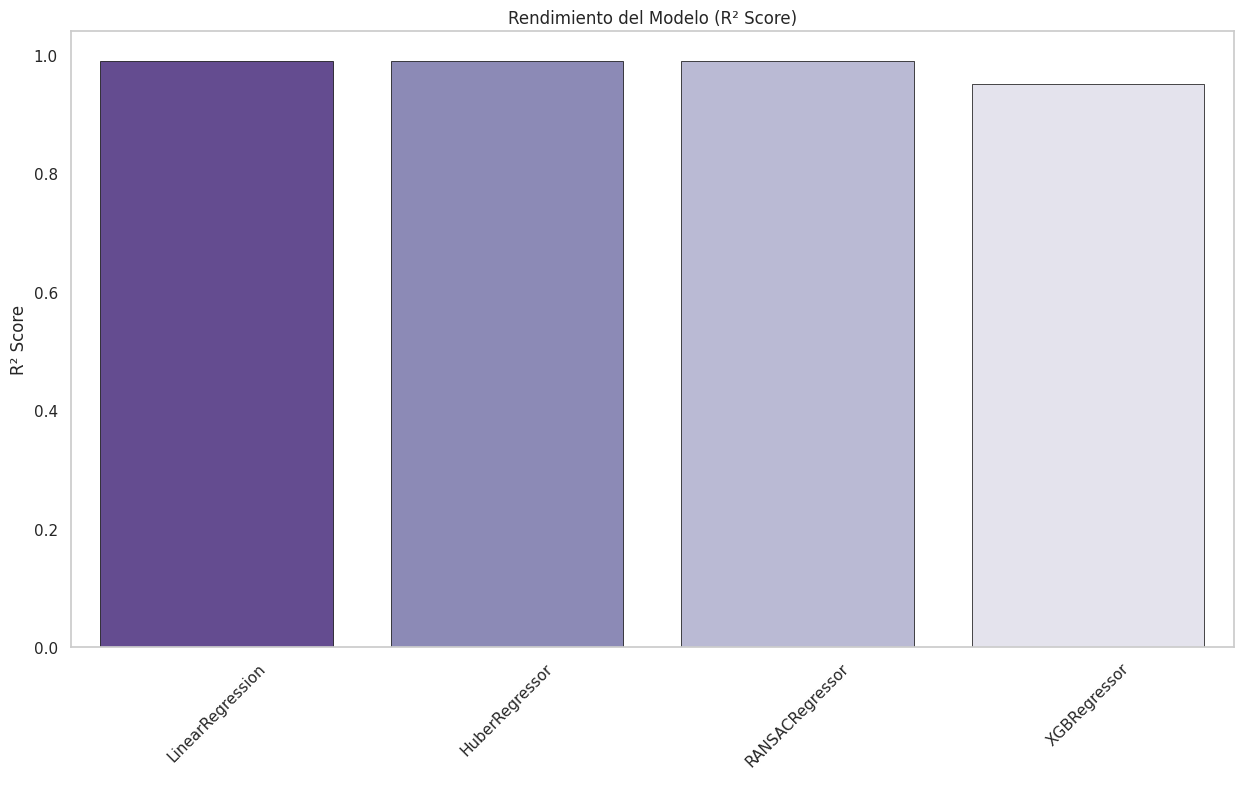

In [92]:
metricas_df = evaluar_modelos(modelos, X_train, y_train, X_test, y_test)
metricas_df

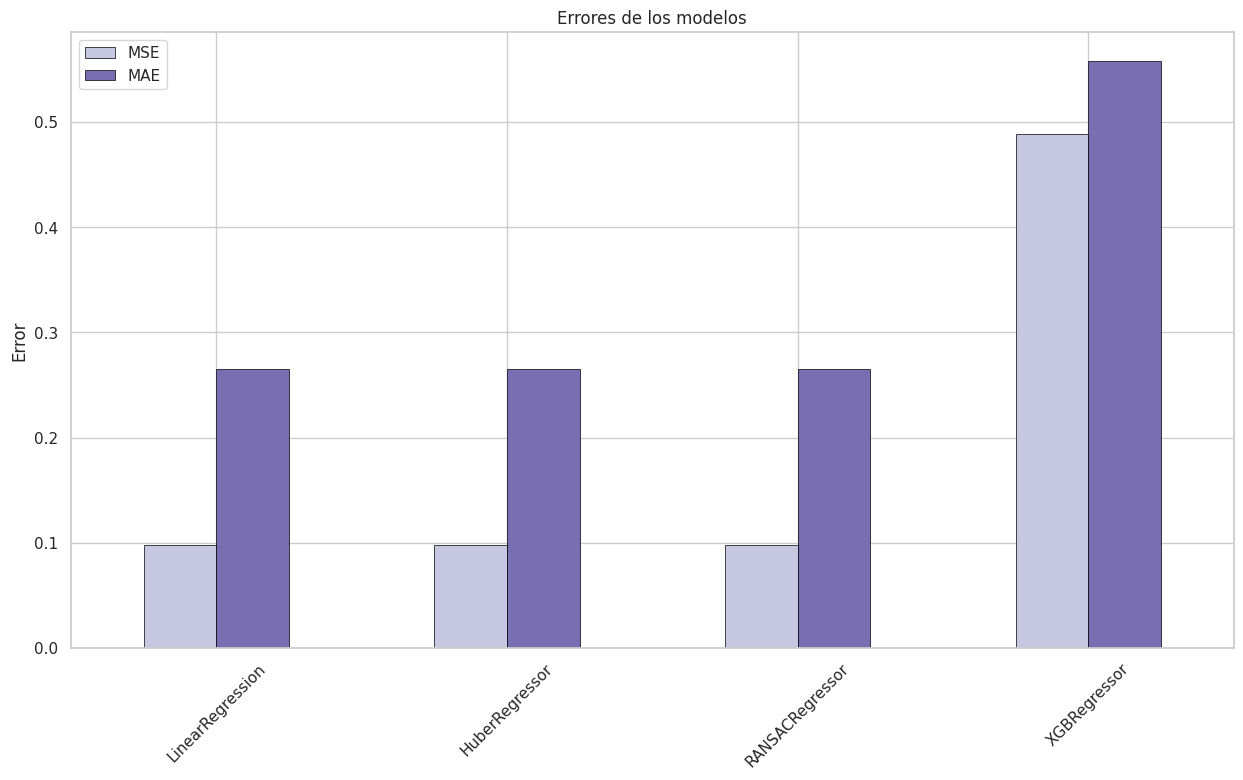

In [90]:
sns.set(style="whitegrid")
colors = sns.color_palette("Purples", len(metricas_df[['MSE', 'MAE']].columns))
ax = metricas_df[['MSE', 'MAE']].plot(kind='bar', figsize=(15, 8), color=colors)

# Add black edges to bars
for container in ax.containers:
    for bar in container:
        bar.set_edgecolor('black')
        bar.set_linewidth(0.5)

plt.title('Errores de los modelos')
plt.xlabel('')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.show()

PCA

Varianza explicada por cada componente:
[0.54335332 0.3449305  0.08849958]


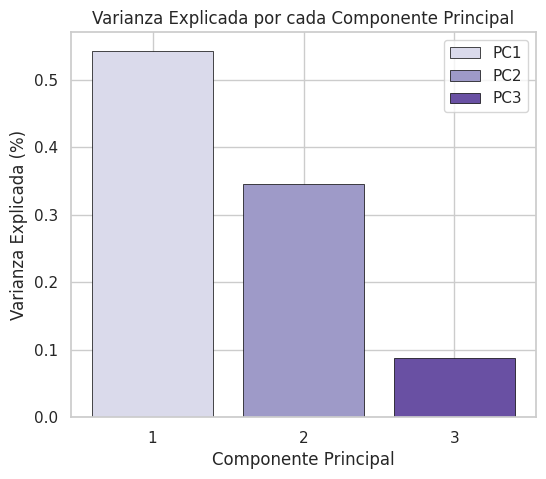

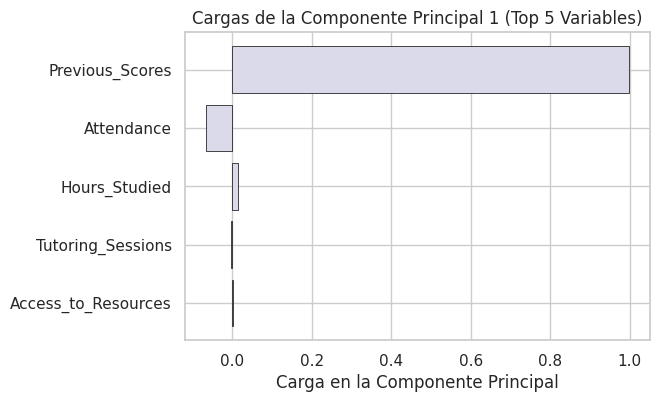

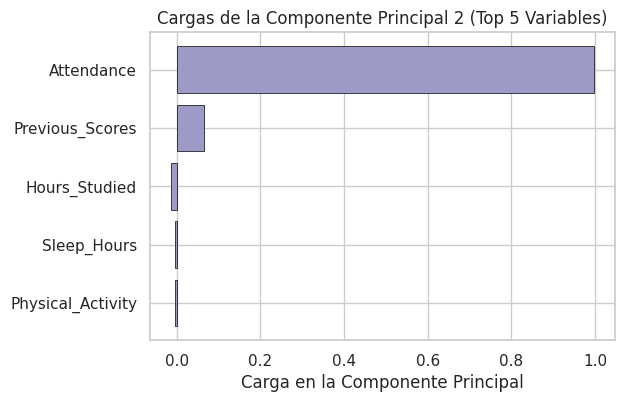

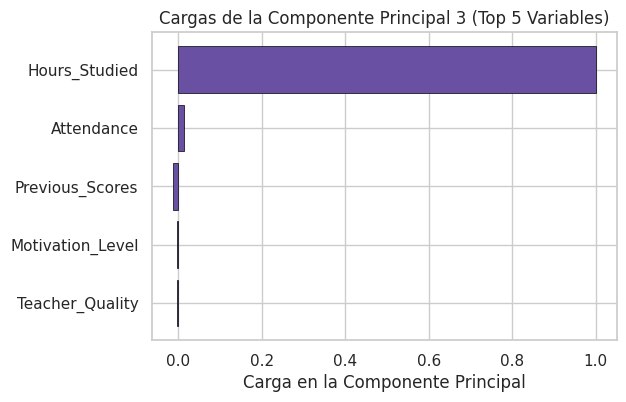

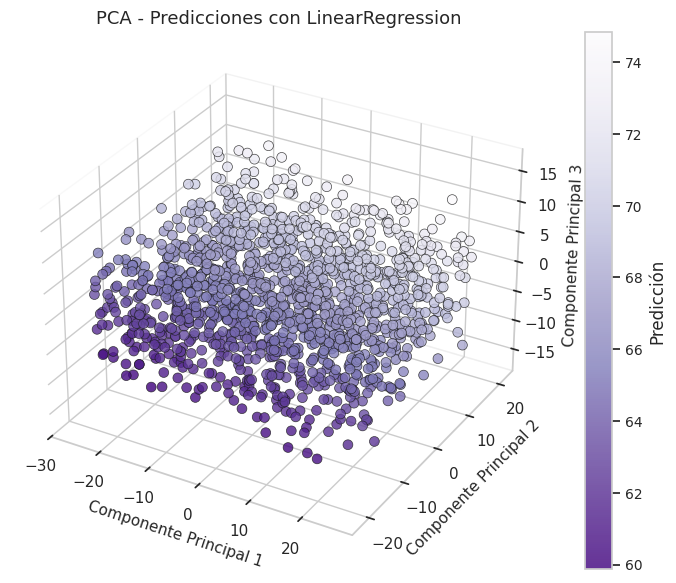

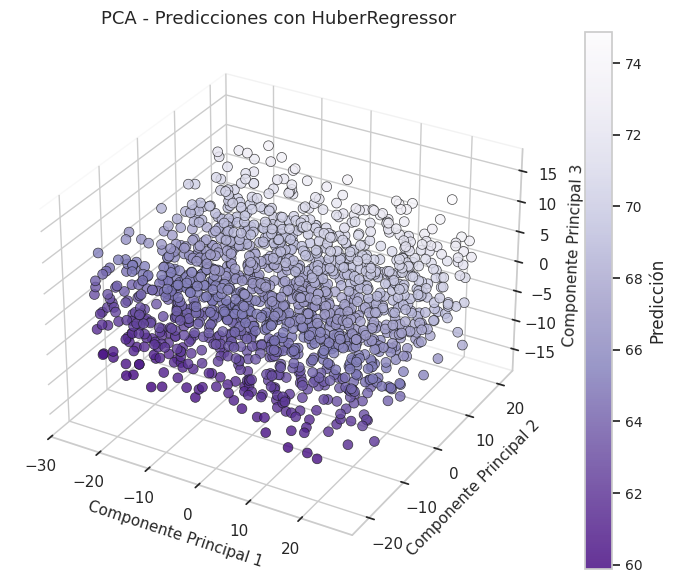

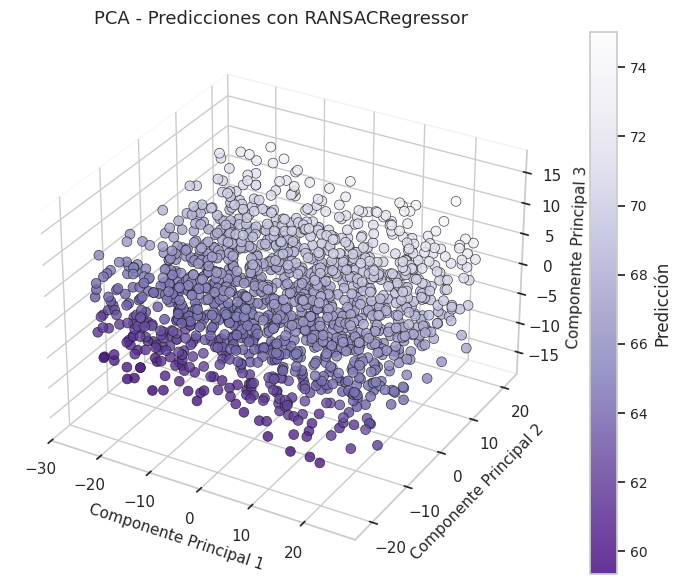

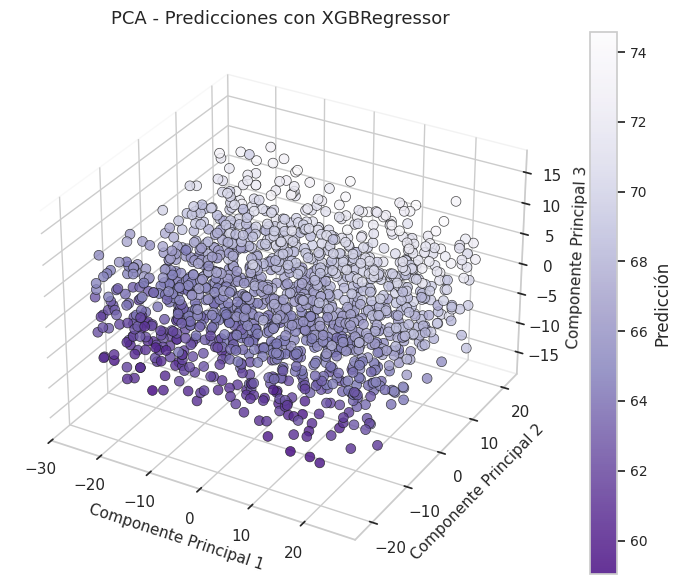

,MSE,MAE,r2,CV Mean r2,CV Std r2
LinearRegression,2.077218,1.172444,0.794242,0.794037,0.008110
HuberRegressor,2.077314,1.172673,0.794232,0.794032,0.008161
RANSACRegressor,2.151164,1.191240,0.786917,0.773727,0.011597
XGBRegressor,2.678303,1.310225,0.734702,0.735118,0.007061


In [88]:
def evaluate_models_pca(models, X_train, y_train, X_test, y_test):
    metrics = {}
    
    # Importamos seaborn para usar su paleta de colores
    import seaborn as sns
    
    # Aplicamos PCA para reducir la dimensionalidad
    pca = PCA(n_components=3)  # 3 componentes principales
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Explicación de la varianza por cada componente
    print("Varianza explicada por cada componente:")
    print(pca.explained_variance_ratio_)
    
    # Obtenemos colores de la paleta 'Purples' de seaborn pero más saturados
    colors = sns.color_palette('Purples', n_colors=3)  # _r invierte la paleta para usar tonos más oscuros
    
    # Visualización de la varianza explicada
    plt.figure(figsize=(6, 5))
    for i, color in enumerate(colors):
        plt.bar(i + 1, pca.explained_variance_ratio_[i], 
               color=color, 
               edgecolor='black',  # Add black edge color
               linewidth=0.5,        # Edge width
               label=f'PC{i+1}')
    
    plt.xlabel('Componente Principal')
    plt.ylabel('Varianza Explicada (%)')
    plt.title('Varianza Explicada por cada Componente Principal')
    plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
    plt.legend()
    plt.show()

    # Crear gráficos para las cargas de las componentes
    feature_names = X_train.columns  
    for i, component in enumerate(pca.components_):
        # Obtener los índices de las 5 variables con mayores cargas en valor absoluto
        abs_component = np.abs(component)  
        top_5_indices = np.argsort(abs_component)[-5:]  # Obtener los índices de las 5 más grandes

        # Extraer las 5 características con las mayores cargas
        top_5_features = [feature_names[idx] for idx in top_5_indices]
        top_5_loadings = component[top_5_indices]

        plt.figure(figsize=(6, 4))
        plt.barh(top_5_features, top_5_loadings, 
                color=colors[i],
                edgecolor='black',    # Add black edge color
                linewidth=0.5)          # Edge width
        plt.xlabel('Carga en la Componente Principal')
        plt.title(f'Cargas de la Componente Principal {i + 1} (Top 5 Variables)')
        plt.show()


    for model in models:
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='r2')
        
        # Entrenamos el modelo con los datos transformados por PCA
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)

        # Métricas de evaluación
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        metrics[model.__class__.__name__] = {
            'MSE': mse, 
            'MAE': mae, 
            'r2': r2, 
            'CV Mean r2': cv_scores.mean(), 
            'CV Std r2': cv_scores.std()
        }

        # Graficar las predicciones en el espacio 3D del PCA
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        
        # Mejoramos la visualización de los puntos
        sc = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], X_test_pca[:, 2], 
                      c=y_pred, 
                      cmap='Purples_r',  # Usamos la versión invertida para colores más intensos
                      s=50,              # Aumentamos el tamaño de los puntos
                      alpha=0.8,         # Ligera transparencia para ver puntos superpuestos
                      edgecolor='k',     # Borde negro para mejor definición
                      linewidth=0.5)     # Grosor del borde
                      
        cbar = plt.colorbar(sc, label='Predicción')
        cbar.ax.tick_params(labelsize=10)  # Tamaño de las etiquetas en la barra de color
        
        ax.set_xlabel('Componente Principal 1', fontsize=11)
        ax.set_ylabel('Componente Principal 2', fontsize=11)
        ax.set_zlabel('Componente Principal 3', fontsize=11)
        ax.set_title(f'PCA - Predicciones con {model.__class__.__name__}', fontsize=13)
        
        # Mejoramos los ejes para mayor claridad
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()

    
    metrics_df = pd.DataFrame(metrics).T
    return metrics_df

# Llamada a la función 
models = [LinearRegression(),
          HuberRegressor(max_iter=1000), 
          RANSACRegressor(),
          XGBRegressor()]

metrics_df = evaluate_models_pca(models, X_train, y_train, X_test, y_test)
metrics_df

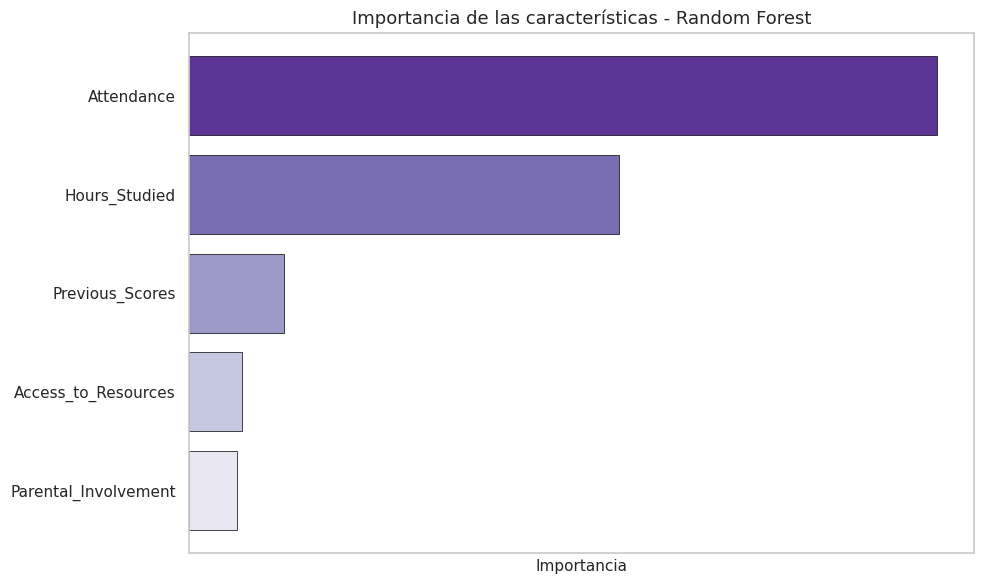

In [81]:
# Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Obtener la importancia de las características
importances = rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Seleccionar las 5 características más importantes
top_5 = importance_df.head(5)
top_5 = top_5.iloc[::-1]  # Invertir para mostrar en orden ascendente

# Importar seaborn si aún no está importado
import seaborn as sns

# Usar la paleta 'Purples_r' para mantener consistencia con los gráficos anteriores
colors = sns.color_palette('Purples', n_colors=len(top_5))

plt.figure(figsize=(10,6))
bars = plt.barh(top_5['Feature'], top_5['Importance'], color=colors)
plt.xlabel('Importancia', fontsize=11)
plt.title('Importancia de las características - Random Forest', fontsize=13)

# Mantener la configuración original
plt.grid(False)
plt.xticks([])

# Añadir bordes para mayor definición, similar a los scatter plots
for bar in bars:
    bar.set_edgecolor('black')
    bar.set_linewidth(0.5)

plt.tight_layout()
plt.show()